In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from pathlib import Path

# 01 — Preprocessing and data analysis

**Workflow in this notebook**

1. **Load data**
2. **Scrutinize** — missing values, units, censored relations (`>`, `<`), duplicates
3. **Define target** — assign **pIC50**, verify against pChEMBL
4. **Visualize** — distributions, outliers, unit mix, relation types
5. **Aggregate** — one row per molecule
6. **Save** — `processed/molecules_clean.csv` for feature engineering and training notebooks


## 1. Load data


In [113]:
data = pd.read_csv('./molecules.csv', sep=';')
print(f"Rows: {len(data):,}  |  Columns: {len(data.columns)}")
data.head(3)

Rows: 26,600  |  Columns: 48


,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL3808884,NaN,NaN,562.55,2.0,6.04,6z,COC(=O)c1cc2cc(NCc3cc(NC(=O)c4cc(-n5cnc(C)c5)c...,IC50,'=',...,CHEMBL3808348,1,Scientific Literature,J Med Chem,2016.0,NaN,NaN,NaN,NaN,112.0
1,CHEMBL138940,NaN,NaN,513.96,1.0,2.89,31,O=C(/C=C/C(=O)Nc1cc2c(Nc3ccc(F)c(Cl)c3)ncnc2cn...,IC50,'=',...,CHEMBL1134843,1,Scientific Literature,J Med Chem,2001.0,CHEMBL3307523,NaN,NaN,NaN,14.0
2,CHEMBL4079501,NaN,NaN,485.59,0.0,4.50,6f,C=CC(=O)Nc1cc(Nc2n[nH]c3cc(-c4ccncc4)ccc23)c(O...,IC50,'=',...,CHEMBL4007434,1,Scientific Literature,J Med Chem,2017.0,NaN,NaN,NaN,NaN,5.0


## 2. Scrutinize — structure & quality

Check before trusting `Standard Value` as the label.


In [114]:
# Columns we care about for IC50 / target definition
KEY_COLS = ['Molecule ChEMBL ID', 'Molecule Name', 'Smiles', 'Standard Type', 'Standard Relation', 'Standard Value', 'Standard Units', 'pChEMBL Value']

# Missing counts on key fields
missing = data[KEY_COLS].isna().sum().sort_values(ascending=False)
print("Number of missing values per attribute:")
display(missing)

# Basic counts
print(f"\nUnique molecules: {data['Molecule ChEMBL ID'].nunique():,}")
print(f"Rows per molecule (mean): {len(data) / data['Molecule ChEMBL ID'].nunique():.2f}")
print(f"\nStandard Type:\n{data['Standard Type'].value_counts().to_string()}")
print(f"\nStandard Units:\n{data['Standard Units'].value_counts(dropna=False).head(10).to_string()}")
print(f"\nStandard Relation:\n{data['Standard Relation'].value_counts().to_string()}")

# Sanity check — this export is EGFR-only (epidermal growth factor receptor)
n = len(data)
print(f"\nEGFR: {n:,} / {n:,} rows (100%)")

Number of missing values per attribute:


Molecule Name         23662
pChEMBL Value          7222
Standard Value         1401
Standard Relation      1398
Standard Units         1259
Smiles                   47
Molecule ChEMBL ID        0
Standard Type             0
dtype: int64


Unique molecules: 14,776
Rows per molecule (mean): 1.80

Standard Type:
Standard Type
IC50    26600

Standard Units:
Standard Units
nM             25244
NaN             1259
ug.mL-1           89
/uM                6
10^-5 mol/L        1
10^3 uM            1

Standard Relation:
Standard Relation
'='     19719
'>'      3309
'<'      2067
'<='       87
'>>'       11
'>='        8
'~'         1

EGFR: 26,600 / 26,600 rows (100%)


In [115]:
# SMILES validity (RDKit) — how many rows can we featurize?
def is_valid_smiles(s):
    if pd.isna(s):
        return False
    return Chem.MolFromSmiles(str(s)) is not None

data['smiles_valid'] = data['Smiles'].map(is_valid_smiles)
print(data['smiles_valid'].value_counts())

smiles_valid
True     26553
False       47
Name: count, dtype: int64


## 3. Define target — pIC50

**Target variable: `pIC50`**

IC50 is a quantitative measurement used in pharmacology, biochemistry and toxicology to indicate how much of a specific substance (like a drug, inhibitor, or toxicant) is needed to inhibit a given biological or biochemical process by 50%. 
For IC50 expressed in **nM**, pIC50 is defined as:

`pIC50 = -log10(Standard Value × 1e-9)`  (i.e. `-log10(IC50 in M)`)

This is the same scale as ChEMBL's **`pChEMBL Value`** column.

**Assignment rule (per row):**

| Situation | What we do |
|-----------|------------|
| `Standard Value` + `pChEMBL Value` both present | Compute pIC50 from Standard Value and **check** it matches pChEMBL (within tolerance). Use the value if they agree; flag mismatches. |
| Only `Standard Value` present | **Compute** pIC50 from Standard Value (nM → M). |
| Missing / invalid IC50 | Drop or exclude from modeling set |

Higher pIC50 = more potent → **maximize** in the GA.


In [116]:
PCHEMBL_TOLERANCE = 0.01  # max |computed pIC50 - pChEMBL| to treat as agreement


def ic50_nm_to_pIC50(ic50_nm: float) -> float:
    return -np.log10(ic50_nm * 1e-9)


def assign_pIC50(standard_value, pchembl_value, tolerance=PCHEMBL_TOLERANCE):
    """Return pIC50 and a source label; NaN if IC50 invalid or pChEMBL disagrees."""
    if pd.isna(standard_value) or standard_value <= 0:
        return np.nan, 'invalid_ic50'

    computed = ic50_nm_to_pIC50(standard_value)

    if pd.notna(pchembl_value):
        if abs(computed - pchembl_value) <= tolerance:
            return pchembl_value, 'pchembl_verified'
        return np.nan, 'pchembl_mismatch'

    return computed, 'computed_from_ic50'


# Standard Value sanity checks
sv = data['Standard Value'].dropna()
print(sv.describe())
print(f"\nNon-positive values: {(sv <= 0).sum()}")
print(f"Rows with missing Standard Value: {data['Standard Value'].isna().sum()}")

# Work on nM rows with positive IC50
nm_positive = data.loc[
    (data['Standard Units'] == 'nM') & (data['Standard Value'] > 0)
].copy()
nm_positive['pIC50_computed'] = ic50_nm_to_pIC50(nm_positive['Standard Value'])

assigned = nm_positive.apply(
    lambda r: assign_pIC50(r['Standard Value'], r['pChEMBL Value']),
    axis=1,
    result_type='expand',
)
nm_positive['pIC50'] = assigned[0]
nm_positive['pIC50_source'] = assigned[1]

print("\npIC50 source breakdown (nM, positive IC50):")
print(nm_positive['pIC50_source'].value_counts().to_string())

both = nm_positive.dropna(subset=['pChEMBL Value'])
if len(both):
    diff = (both['pIC50_computed'] - both['pChEMBL Value']).abs()
    print(f"\n|computed pIC50 - pChEMBL| median: {diff.median():.4f}  max: {diff.max():.4f}")
    print(f"Rows within tolerance ({PCHEMBL_TOLERANCE}): {(diff <= PCHEMBL_TOLERANCE).sum():,} / {len(both):,}")

print("\npIC50 range (assigned):")
print(nm_positive['pIC50'].describe())

count    2.519900e+04
mean     3.000612e+06
std      4.760843e+07
min      5.012000e-09
25%      1.200000e+01
50%      1.000000e+02
75%      1.500000e+03
max      9.332543e+08
Name: Standard Value, dtype: float64

Non-positive values: 0
Rows with missing Standard Value: 1401

pIC50 source breakdown (nM, positive IC50):
pIC50_source
pchembl_verified      19378
computed_from_ic50     5724

|computed pIC50 - pChEMBL| median: 0.0021  max: 0.0055
Rows within tolerance (0.01): 19,378 / 19,378

pIC50 range (assigned):
count    25102.000000
mean         6.807458
std          1.511042
min          0.030000
25%          5.820000
50%          7.000000
75%          7.910000
max         17.299989
Name: pIC50, dtype: float64


## 4. Visualize — understanding the data


pIC50 (exact only, n=19,643): μ = 7.059, σ² = 1.911, σ = 1.383


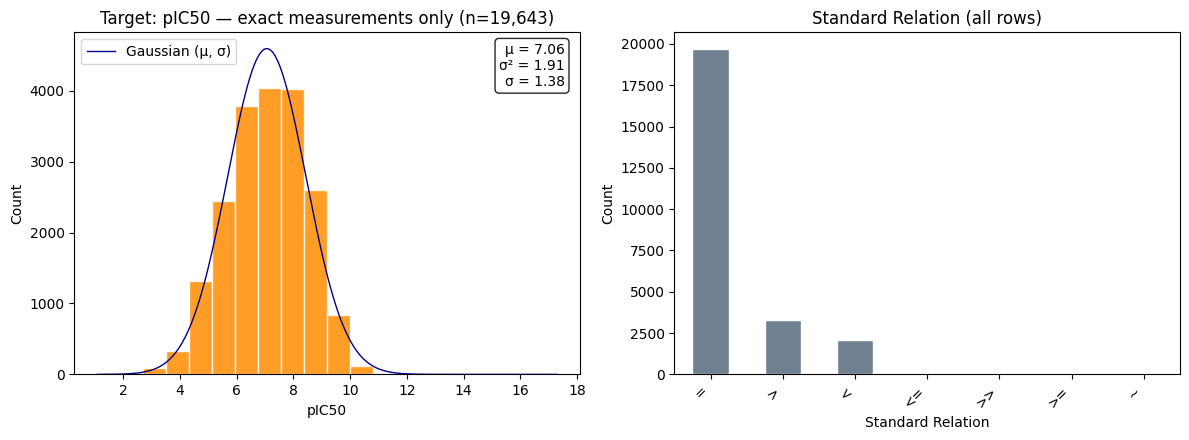

In [117]:
# Exact IC50 only
plot_df = nm_positive[
    (nm_positive['Standard Relation'] == "'='") & nm_positive['pIC50'].notna()
].copy()

pIC50 = plot_df['pIC50']
mu = pIC50.mean()
var = pIC50.var(ddof=1) # Set ddof to 1 for Bessel's correction
sigma = pIC50.std(ddof=1)
print(f"pIC50 (exact only, n={len(pIC50):,}): μ = {mu:.3f}, σ² = {var:.3f}, σ = {sigma:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Target: pIC50 + Gaussian overlay (μ, σ from sample)
ax = axes[0]
counts, bin_edges, _ = ax.hist(
    pIC50, bins=20, color='darkorange', edgecolor='white', alpha=0.85
)
bin_width = bin_edges[1] - bin_edges[0]
x = np.linspace(bin_edges[0], bin_edges[-1], 200)
gaussian = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
ax.plot(x, gaussian * len(pIC50) * bin_width, color='darkblue', lw=1, label='Gaussian (μ, σ)')

ax.set_xlabel('pIC50')
ax.set_ylabel('Count')
ax.set_title(f'Target: pIC50 — exact measurements only (n={len(pIC50):,})')
ax.legend(loc='upper left')
ax.text(
    0.97, 0.97,
    f'μ = {mu:.2f}\nσ² = {var:.2f}\nσ = {sigma:.2f}',
    transform=ax.transAxes, va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
)

# Censoring — exact vs bound measurements (full dataset)
ax = axes[1]
rel = data['Standard Relation'].astype(str).str.strip("'")
rel.value_counts().plot(kind='bar', ax=ax, color='slategray', edgecolor='white')
ax.set_title('Standard Relation (all rows)')
ax.set_ylabel('Count')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

Exact nM rows (relation '='): 19,643
Molecules with 1 exact row: 6,668
Molecules with 2+ exact rows: 4,183
Max exact rows for one molecule: 263

pIC50 spread (molecules with 2+ exact nM measurements):


count    4183.000000
mean        0.957563
std         0.977326
min         0.000000
25%         0.130000
50%         0.740000
75%         1.415000
max         8.539078
Name: pIC50_range, dtype: float64


Median ΔpIC50 = 0.74 (≈ 5.5× IC50 fold)


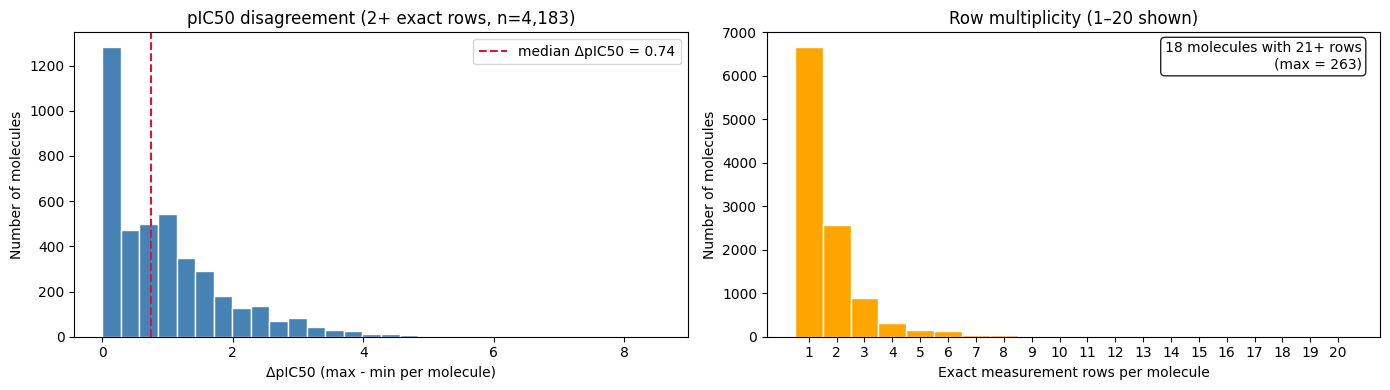

Molecules by exact row count (selected):
    1 rows: 6,668 molecules
    2 rows: 2,562 molecules
    3 rows: 892 molecules
    4 rows: 318 molecules
    5 rows: 147 molecules
   10 rows: 7 molecules
  263 rows: 1 molecules
  … total unique molecules: 10,851

pIC50 source mix:


pIC50_source
pchembl_verified      19378
computed_from_ic50      265
Name: count, dtype: int64

In [118]:
# Duplicate molecules — same ID, different pIC50? (exact nM IC50 only)
exact = nm_positive[nm_positive['Standard Relation'] == "'='"].copy()

dup_counts = exact.groupby('Molecule ChEMBL ID').size()
print(f"Exact nM rows (relation '='): {len(exact):,}")
print(f"Molecules with 1 exact row: {(dup_counts == 1).sum():,}")
print(f"Molecules with 2+ exact rows: {(dup_counts > 1).sum():,}")
print(f"Max exact rows for one molecule: {dup_counts.max()}")

multi = exact[exact['Molecule ChEMBL ID'].isin(dup_counts[dup_counts > 1].index)]
spread = multi.groupby('Molecule ChEMBL ID').agg(
    count=('pIC50', 'size'),
    pIC50_min=('pIC50', 'min'),
    pIC50_max=('pIC50', 'max'),
)
# pIC50 is on a log scale → spread = subtract. ΔpIC50 ≈ 1 means ~10× IC50 fold.
spread['pIC50_range'] = spread['pIC50_max'] - spread['pIC50_min']

print("\npIC50 spread (molecules with 2+ exact nM measurements):")
display(spread['pIC50_range'].describe())

median_range = spread['pIC50_range'].median()
print(
    f"\nMedian ΔpIC50 = {median_range:.2f} "
    f"(≈ {10 ** median_range:.1f}× IC50 fold)"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# pIC50 disagreement (molecules with 2+ exact rows)
ax = axes[0]
ax.hist(spread['pIC50_range'], bins=30, color='steelblue', edgecolor='white')
ax.axvline(
    median_range, color='crimson', ls='--', lw=1.5,
    label=f'median ΔpIC50 = {median_range:.2f}',
)
ax.set_xlabel('ΔpIC50 (max - min per molecule)')
ax.set_ylabel('Number of molecules')
ax.set_title(f'pIC50 disagreement (2+ exact rows, n={len(spread):,})')
ax.legend()

# Row multiplicity (all molecules in exact)
ax = axes[1]
ax.hist(
    dup_counts,
    bins=np.arange(0.5, 21.5, 1),
    color='orange',
    edgecolor='white',
    align='mid',
)
tail = (dup_counts > 20).sum()
ax.set_xlabel('Exact measurement rows per molecule')
ax.set_ylabel('Number of molecules')
ax.set_title('Row multiplicity (1–20 shown)')
ax.set_xticks(range(1, 21))
if tail:
    ax.text(
        0.97, 0.97,
        f'{tail:,} molecules with 21+ rows\n(max = {dup_counts.max()})',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85),
    )

plt.tight_layout()
plt.show()

vc = dup_counts.value_counts().sort_index()
print('Molecules by exact row count (selected):')
for n in [1, 2, 3, 4, 5, 10, dup_counts.max()]:
    if n in vc.index:
        print(f'  {int(n):>3} rows: {vc[n]:,} molecules')
print(f'  … total unique molecules: {len(dup_counts):,}')

print("\npIC50 source mix:")
display(exact['pIC50_source'].value_counts())

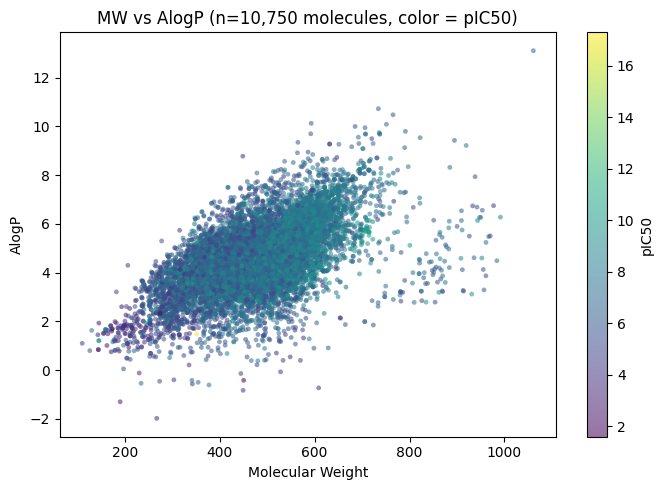

In [119]:
chem_viz = (
    exact.sort_values('pIC50', ascending=False)
    .groupby('Molecule ChEMBL ID', as_index=False)
    .first()[['Molecular Weight', 'AlogP', 'pIC50']]
    .dropna(subset=['Molecular Weight', 'AlogP', 'pIC50'])
)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    chem_viz['Molecular Weight'],
    chem_viz['AlogP'],
    c=chem_viz['pIC50'],
    cmap='viridis',
    alpha=0.55,
    s=12,
    edgecolors='none',
)
ax.set_xlabel('Molecular Weight')
ax.set_ylabel('AlogP')
ax.set_title(f'MW vs AlogP (n={len(chem_viz):,} molecules, color = pIC50)')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('pIC50')
plt.tight_layout()
plt.show()

MW vs AlogP (n ≈ 10.8k, one compound per ID, color = pIC50) shows a dense core at MW 300–600 and AlogP 2–7, with a long tail of larger, more lipophilic compounds. Potency (pIC50) varies across this space without a strong MW/AlogP gradient; very high pIC50 values are rare and not confined to one region. Weaker compounds appear somewhat more often at low MW and low AlogP. Potency in this set is not dominated by size and lipophilicity alone, so structure-based features are appropriate for modeling; MW/AlogP alone are unlikely to be sufficient.

## 5. Aggregate — one row per molecule

**Filters:**

1. `Standard Units == 'nM'`
2. `Standard Relation == "'='"` (exact measurements only for v1)
3. `Standard Value > 0`
4. Valid SMILES
5. Assign **pIC50** per row (`assign_pIC50`): verify against `pChEMBL Value` when both exist
6. One row per `Molecule ChEMBL ID` — aggregate with **max pIC50** (best potency per molecule)


In [120]:
funnel = []


def _funnel_record(df, step):
    funnel.append({
        'step': step,
        'rows': len(df),
        'molecules': df['Molecule ChEMBL ID'].nunique(),
    })


_funnel_record(data, '0. Raw export')

clean = data.copy()
clean = clean[clean['Standard Units'] == 'nM']
_funnel_record(clean, '1. Standard Units == nM')

clean = clean[clean['Standard Relation'] == "'='"]
_funnel_record(clean, '2. Standard Relation == =')

clean = clean[clean['Standard Value'] > 0]
_funnel_record(clean, '3. Standard Value > 0')

assert 'smiles_valid' in data.columns, (
    'Run the SMILES validation cell in §2 before aggregating.'
)
clean = clean[clean['smiles_valid']]
_funnel_record(clean, '4. Valid SMILES')

# Assign pIC50 row by row
assigned = clean.apply(
    lambda r: assign_pIC50(r['Standard Value'], r['pChEMBL Value']),
    axis=1,
    result_type='expand',
)
clean['pIC50'] = assigned[0]
clean['pIC50_source'] = assigned[1]
clean = clean.dropna(subset=['pIC50'])
_funnel_record(clean, '5. pIC50 assigned')


In [121]:
# One row per molecule — keep best potency (max pIC50)
clean = (
    clean.sort_values('pIC50', ascending=False)
    .groupby('Molecule ChEMBL ID', as_index=False)
    .agg({
        'Smiles': 'first',
        'Molecule Name': 'first',
        'Standard Value': 'first',
        'pChEMBL Value': 'first',
        'pIC50': 'first',
        'pIC50_source': 'first',
        'Standard Units': 'first',
        'Target Name': 'first',
    })
)

clean['target'] = clean['pIC50']
_funnel_record(clean, '6. One row per molecule (max pIC50)')

funnel_df = pd.DataFrame(funnel)
base_rows = funnel_df['rows'].iloc[0]
base_mols = funnel_df['molecules'].iloc[0]
funnel_df['rows_%'] = (funnel_df['rows'] / base_rows * 100).round(1)
funnel_df['molecules_%'] = (funnel_df['molecules'] / base_mols * 100).round(1)

print('Filter funnel:')
display(funnel_df)

print(f"\nClean rows: {len(clean):,}")
print(clean['pIC50_source'].value_counts().to_string())
display(clean[['Molecule ChEMBL ID', 'Smiles', 'Standard Value', 'pChEMBL Value', 'pIC50', 'pIC50_source']].head())

Filter funnel:


,step,rows,molecules,rows_%,molecules_%
0,0. Raw export,26600,14776,100.0,100.0
1,1. Standard Units == nM,25244,13698,94.9,92.7
2,2. Standard Relation == =,19646,10853,73.9,73.5
3,3. Standard Value > 0,19643,10851,73.8,73.4
4,4. Valid SMILES,19626,10834,73.8,73.3
5,5. pIC50 assigned,19626,10834,73.8,73.3
6,6. One row per molecule (max pIC50),10834,10834,40.7,73.3



Clean rows: 10,834
pIC50_source
pchembl_verified      10720
computed_from_ic50      114


,Molecule ChEMBL ID,Smiles,Standard Value,pChEMBL Value,pIC50,pIC50_source
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,10000.0,5.00,5.00,pchembl_verified
1,CHEMBL100714,COc1ccc(Nc2ncnc3cc(OC)c(OC)cc23)cc1OC,2800.0,5.55,5.55,pchembl_verified
2,CHEMBL1009,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O,2880.0,5.54,5.54,pchembl_verified
3,CHEMBL101253,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,457.7,6.34,6.34,pchembl_verified
4,CHEMBL101581,COc1cc2nccc(Oc3cccc(Br)c3)c2cc1OC,2500.0,5.60,5.60,pchembl_verified


**Why aggregate with max pIC50?**

The same compound often appears in many assay rows with different measured potencies (our duplicate analysis shows substantial ΔpIC50 spread). For SMILES → pIC50 modeling we need exactly one label per molecule: keeping all rows would leak duplicates across train/test splits and teach the model conflicting targets for the same structure. Taking **max pIC50** answers the question “how potent can this compound be in our data?” — which matches our direction of interest (higher pIC50 = more potent) and how we will use predictions later in the GA. Mean or median would pull labels toward weaker or noisy assays; min would be overly pessimistic. Max is a standard, defensible choice, after restricting to exact nM measurements, with the caveat that it is slightly optimistic when many heterogeneous assays are mixed.


## 6. Save

Write `processed/molecules_clean.csv` for downstream feature engineering and training notebooks.


In [122]:
OUT_PATH = Path('processed/molecules_clean.csv')
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
clean.to_csv(OUT_PATH, index=False)
print(f'\nSaved: {OUT_PATH.resolve()} ({len(clean):,} molecules)')


Saved: /Users/lazarsavic/Desktop/DrugDiscovery/data/processed/molecules_clean.csv (10,834 molecules)
